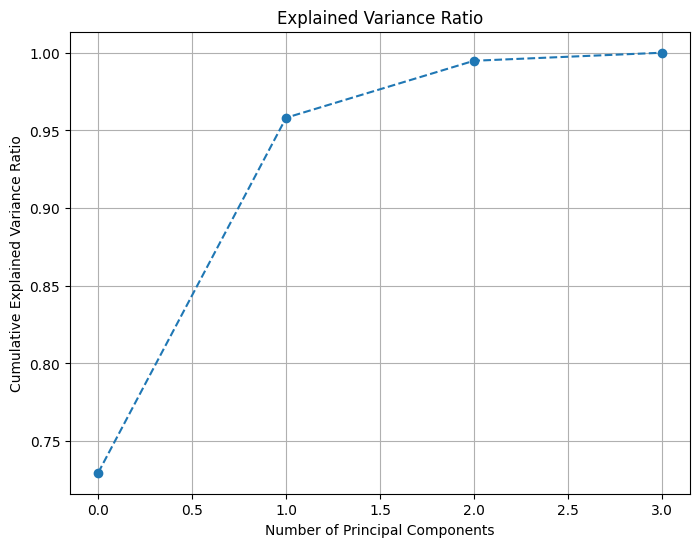

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Iris dataset
iris = load_iris()

iris_df = pd.DataFrame(
    data=np.c_[iris['data'], iris['target']],
    columns=iris['feature_names'] + ['target']
)

# Features and target
X = iris_df.drop('target', axis=1)
y = iris_df['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()                 # <-- pca is defined HERE
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
plt.figure(figsize=(8, 6))
plt.plot(
    np.cumsum(explained_variance_ratio),
    marker='o',
    linestyle='--'
)
plt.title('Explained Variance Ratio')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()




In [10]:
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
n_components = np.argmax(cumulative_variance_ratio >= 0.95) + 1

print(f'Number of principal components to explain 95% variance: {n_components}')


Number of principal components to explain 95% variance: 2


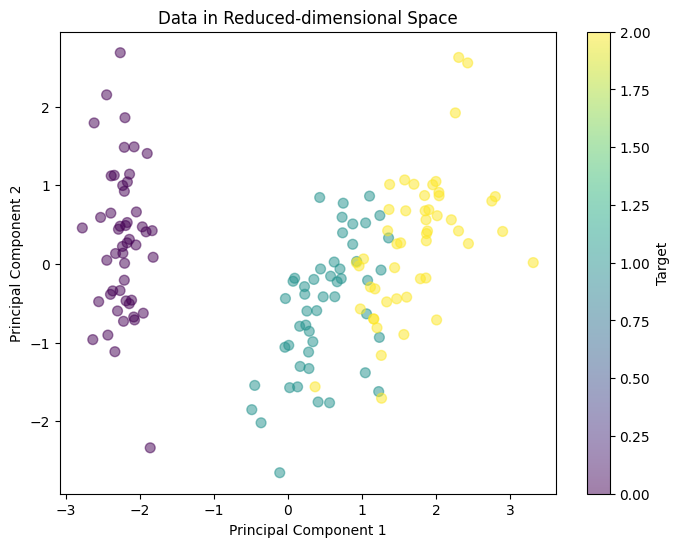

In [11]:
pca = PCA(n_components=n_components)
X_reduced = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=y,
    cmap='viridis',
    s=50,
    alpha=0.5
)
plt.title('Data in Reduced-dimensional Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Target')
plt.show()

